In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from pangya_physics import CLUBS, Wind, find_power

In [2]:
club = CLUBS["1W"]
target_distance = 200
target_height = 0

wind_speeds = [0, 2, 4, 6, 8, 10]

In [3]:
resultados_favor = []

for speed in wind_speeds:
    wind = Wind(speed=speed, degree=0)

    result = find_power(
        club=club,
        wind=wind,
        target_distance=target_distance,
        target_height=target_height,
    )

    resultados_favor.append({
        "Cenário": "Vento favorável",
        "Velocidade do Vento": speed,
        "Direção": 0,
        "Power %": round(result.power_percent * 100, 2),
        "Distância Final": round(result.final_distance, 2),
        "Erro": round(result.error, 2),
        "Iterações": result.iterations,
    })

df_favor = pd.DataFrame(resultados_favor)
df_favor

,Cenário,Velocidade do Vento,Direção,Power %,Distância Final,Erro,Iterações
0,Vento favorável,0,0,70.12,200.69,-0.69,60
1,Vento favorável,2,0,70.12,201.51,-1.51,60
2,Vento favorável,4,0,70.09,199.99,0.01,12
3,Vento favorável,6,0,69.77,200.03,-0.03,9
4,Vento favorável,8,0,69.41,199.99,0.01,10
5,Vento favorável,10,0,69.09,200.02,-0.02,12


In [4]:
resultados_contra = []

for speed in wind_speeds:
    wind = Wind(speed=speed, degree=180)

    result = find_power(
        club=club,
        wind=wind,
        target_distance=target_distance,
        target_height=target_height,
    )

    resultados_contra.append({
        "Cenário": "Vento contra",
        "Velocidade do Vento": speed,
        "Direção": 180,
        "Power %": round(result.power_percent * 100, 2),
        "Distância Final": round(result.final_distance, 2),
        "Erro": round(result.error, 2),
        "Iterações": result.iterations,
    })

df_contra = pd.DataFrame(resultados_contra)
df_contra

,Cenário,Velocidade do Vento,Direção,Power %,Distância Final,Erro,Iterações
0,Vento contra,0,180,70.12,200.69,-0.69,60
1,Vento contra,2,180,70.18,200.01,-0.01,11
2,Vento contra,4,180,70.53,200.04,-0.04,11
3,Vento contra,6,180,70.85,199.99,0.01,12
4,Vento contra,8,180,71.17,199.95,0.05,60
5,Vento contra,10,180,71.17,201.27,-1.27,60


In [5]:
df_wind = pd.concat([df_favor, df_contra], ignore_index=True)
df_wind

,Cenário,Velocidade do Vento,Direção,Power %,Distância Final,Erro,Iterações
0,Vento favorável,0,0,70.12,200.69,-0.69,60
1,Vento favorável,2,0,70.12,201.51,-1.51,60
2,Vento favorável,4,0,70.09,199.99,0.01,12
3,Vento favorável,6,0,69.77,200.03,-0.03,9
4,Vento favorável,8,0,69.41,199.99,0.01,10
5,Vento favorável,10,0,69.09,200.02,-0.02,12
6,Vento contra,0,180,70.12,200.69,-0.69,60
7,Vento contra,2,180,70.18,200.01,-0.01,11
8,Vento contra,4,180,70.53,200.04,-0.04,11
9,Vento contra,6,180,70.85,199.99,0.01,12


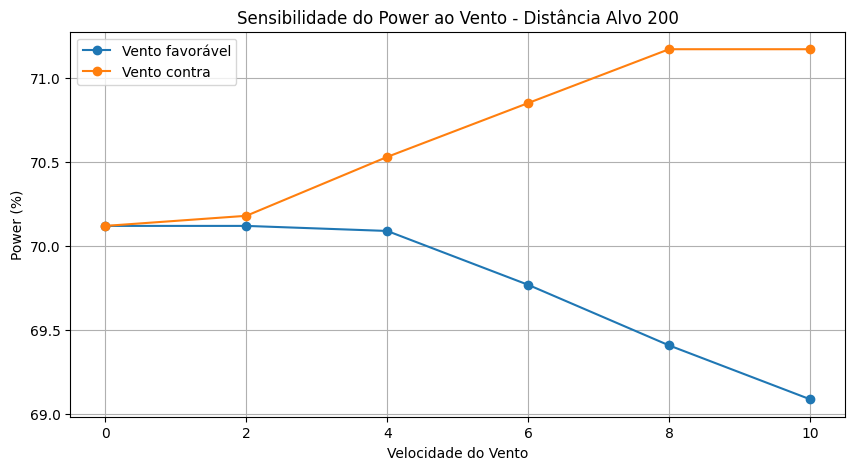

In [6]:
plt.figure(figsize=(10, 5))

for cenario in df_wind["Cenário"].unique():
    subset = df_wind[df_wind["Cenário"] == cenario]

    plt.plot(
        subset["Velocidade do Vento"],
        subset["Power %"],
        marker="o",
        label=cenario,
    )

plt.xlabel("Velocidade do Vento")
plt.ylabel("Power (%)")
plt.title("Sensibilidade do Power ao Vento - Distância Alvo 200")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
wind_degrees = [0, 45, 90, 135, 180, 225, 270, 315]
wind_speed = 5

resultados_direcao = []

for degree in wind_degrees:
    wind = Wind(speed=wind_speed, degree=degree)

    result = find_power(
        club=club,
        wind=wind,
        target_distance=target_distance,
        target_height=target_height,
    )

    resultados_direcao.append({
        "Direção do Vento": degree,
        "Velocidade do Vento": wind_speed,
        "Power %": round(result.power_percent * 100, 2),
        "Desvio Lateral": round(result.desvio, 4),
        "Distância Final": round(result.final_distance, 2),
        "Erro": round(result.error, 2),
    })

df_direcao = pd.DataFrame(resultados_direcao)
df_direcao

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_direcao["Direção do Vento"],
    df_direcao["Desvio Lateral"],
    marker="o",
)

plt.xlabel("Direção do Vento (graus)")
plt.ylabel("Desvio Lateral")
plt.title("Direção do Vento vs Desvio Lateral")
plt.grid(True)
plt.show()